# Sprint 5: Simulación de Impacto Económico (ROI)

Traducimos las predicciones probabilísticas del modelo final Stacking Classifier en valor de negocio utilizando la matriz costo-beneficio del Sprint 1. Buscamos el umbral óptimo de decisión que maximiza el retorno financiero esperado en el conjunto de prueba.

In [1]:
import sys
sys.path.append("../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
# Cargar datos y modelo
df = pd.read_csv("../data/processed/features_data.csv")
X = df.drop(columns=['attrition'])
y = df['attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = joblib.load("../models/final_model.pkl")
y_proba = model.predict_proba(X_test)[:, 1]


In [3]:
# Definición de costos y beneficios del Sprint 1 (Matriz de Confusión Financiera)
benefit_tp = 150    # Beneficio por retener un empleado propenso a fuga (TP)
cost_fp = -20      # Costo de intervención en un empleado que no se fugaría (FP)
cost_fn = -200     # Costo por no intervenir a un empleado que termina fugándose (FN)
benefit_tn = 0     # Sin impacto para Verdaderos Negativos (TN)


In [4]:
# Evaluación de impacto financiero a un umbral estándar de 0.5
y_pred = (y_proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
valor_total = (tp * benefit_tp) + (fp * cost_fp) + (fn * cost_fn) + (tn * benefit_tn)
print(f"Valor esperado total a threshold 0.5: USD {valor_total:,.2f}")


TN: 2011, FP: 357, FN: 369, TP: 63
Valor esperado total a threshold 0.5: USD -71,490.00


In [5]:
# Búsqueda del umbral óptimo para maximizar el valor de negocio
thresholds = np.arange(0.05, 0.95, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    valor_t = (tp_t * benefit_tp) + (fp_t * cost_fp) + (fn_t * cost_fn) + (tn_t * benefit_tn)
    results.append({"threshold": t, "valor": valor_t})

df_thresholds = pd.DataFrame(results)
best = df_thresholds.loc[df_thresholds["valor"].idxmax()]
print(f"Umbral óptimo: {best['threshold']:.2f}")
print(f"Valor máximo esperado en test: USD {best['valor']:,.2f}")


Umbral óptimo: 0.05
Valor máximo esperado en test: USD -20,300.00


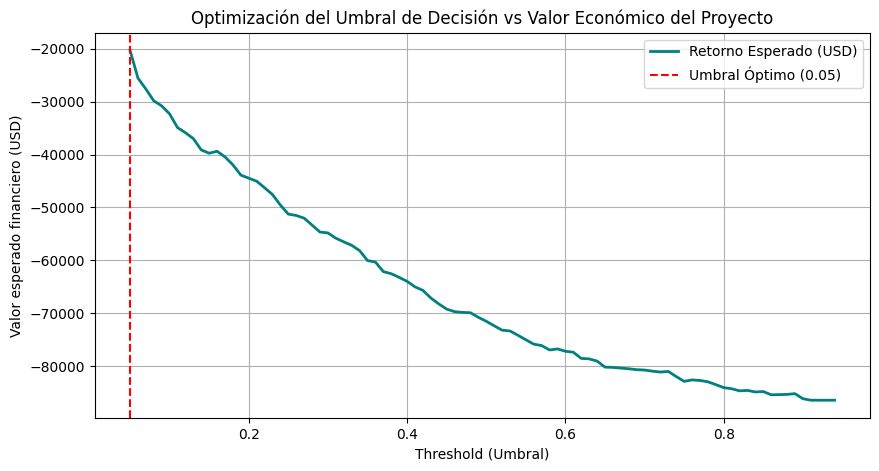

In [6]:
# Visualización de Umbral vs Valor esperado
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["valor"], label="Retorno Esperado (USD)", color='teal', linewidth=2)
plt.axvline(best["threshold"], color="red", linestyle="--", label=f"Umbral Óptimo ({best['threshold']:.2f})")
plt.xlabel("Threshold (Umbral)")
plt.ylabel("Valor esperado financiero (USD)")
plt.title("Optimización del Umbral de Decisión vs Valor Económico del Proyecto")
plt.legend()
plt.grid(True)
plt.show()


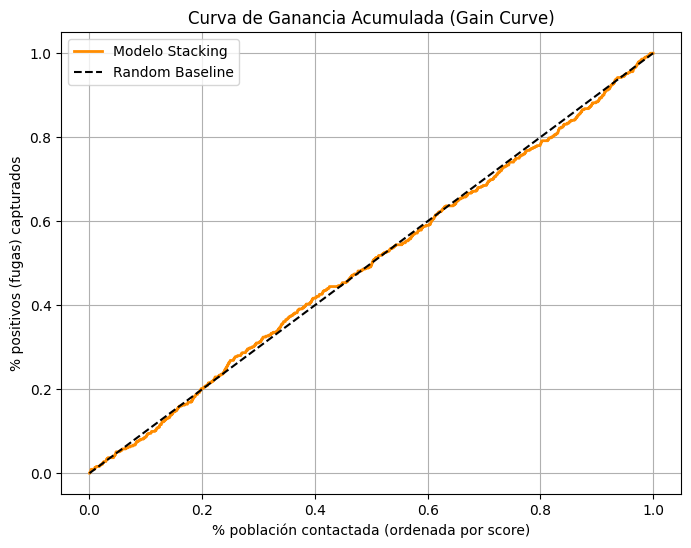

In [7]:
# Gráfico de Gain Curve
order = np.argsort(-y_proba)
y_sorted = y_test.values[order]
cum_pos = np.cumsum(y_sorted)
total_pos = y_test.sum()

x_gain = np.arange(1, len(y_test) + 1) / len(y_test)
y_gain = cum_pos / total_pos

plt.figure(figsize=(8, 6))
plt.plot(x_gain, y_gain, label="Modelo Stacking", color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.xlabel("% población contactada (ordenada por score)")
plt.ylabel("% positivos (fugas) capturados")
plt.title("Curva de Ganancia Acumulada (Gain Curve)")
plt.legend()
plt.grid(True)
plt.show()


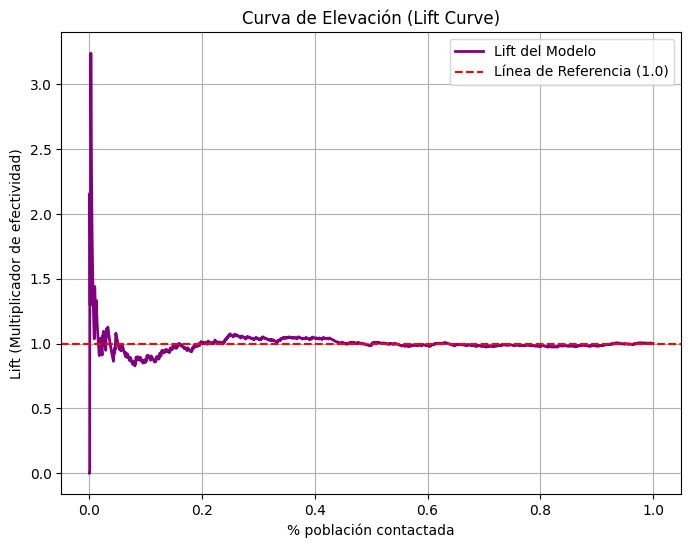

In [8]:
# Gráfico de Lift Curve
lift = y_gain / (x_gain + 1e-9)

plt.figure(figsize=(8, 6))
plt.plot(x_gain, lift, label="Lift del Modelo", color='purple', linewidth=2)
plt.axhline(1.0, color="red", linestyle="--", label="Línea de Referencia (1.0)")
plt.xlabel("% población contactada")
plt.ylabel("Lift (Multiplicador de efectividad)")
plt.title("Curva de Elevación (Lift Curve)")
plt.legend()
plt.grid(True)
plt.show()
